In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
path = "https://raw.githubusercontent.com/SKY-TKP/Machine-Learning-for-IE/refs/heads/main/2110-573%3A%20PATTERN%20RECOG/Assignment/HW2/hr-employee-attrition-with-null.csv"

In [ ]:
# 1. Load Data
df = pd.read_csv(path)
df.head()

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41.0,Yes,Travel_Rarely,NaN,NaN,1.0,NaN,Life Sciences,1.0,...,1.0,80.0,0.0,8.0,0.0,NaN,6.0,NaN,0.0,NaN
1,1,NaN,No,NaN,279.0,Research & Development,NaN,NaN,Life Sciences,1.0,...,4.0,NaN,1.0,10.0,NaN,3.0,10.0,NaN,NaN,7.0
2,2,37.0,Yes,NaN,1373.0,NaN,2.0,2.0,NaN,1.0,...,NaN,80.0,0.0,7.0,3.0,NaN,NaN,0.0,NaN,0.0
3,3,NaN,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,NaN,...,3.0,NaN,NaN,8.0,3.0,NaN,8.0,NaN,3.0,0.0
4,4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,...,4.0,80.0,1.0,6.0,NaN,3.0,2.0,2.0,2.0,NaN


In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [ ]:
# 2. Setup Features
# เลือกเฉพาะคอลัมน์ที่เป็น Numeric มาลองทำ Discretization
features = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany']
X = df[features]
y = df['Attrition']

## Data Exploration

(array([1233.,  237.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

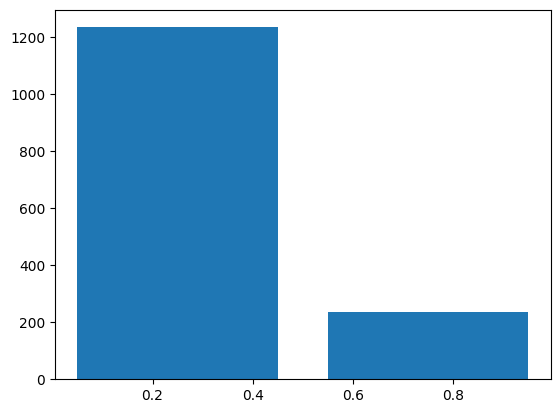

In [ ]:
# Plot histogram of Y
plt.hist(y, bins=2, rwidth=0.8)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'MonthlyIncome'}>],
       [<Axes: title={'center': 'TotalWorkingYears'}>,
        <Axes: title={'center': 'YearsAtCompany'}>]], dtype=object)

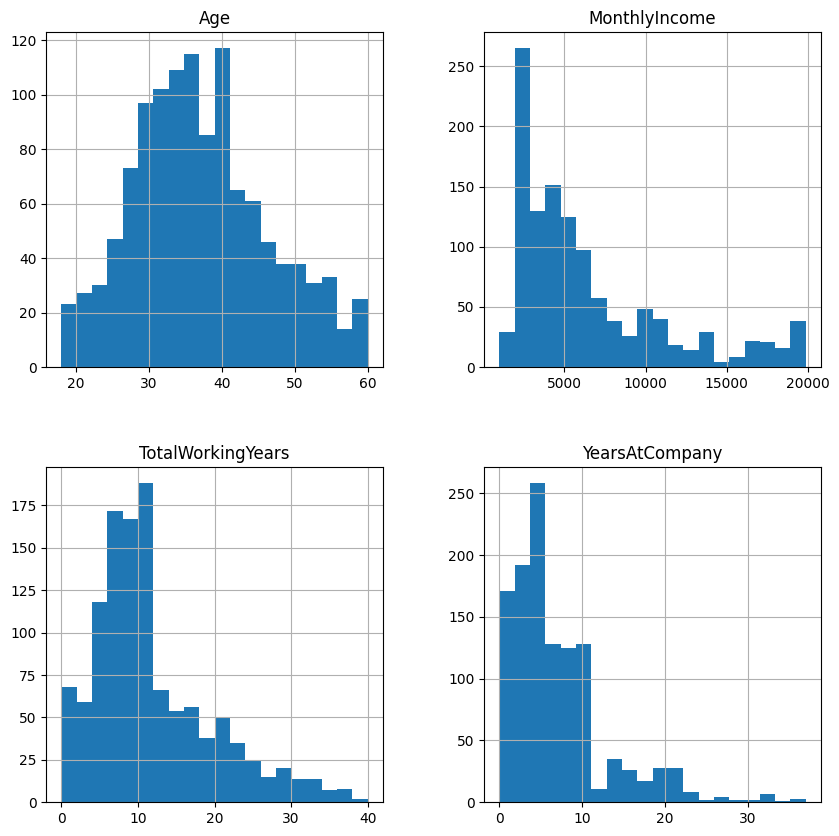

In [ ]:
# Plot histogram of X
X.hist(bins=20, figsize=(10, 10))

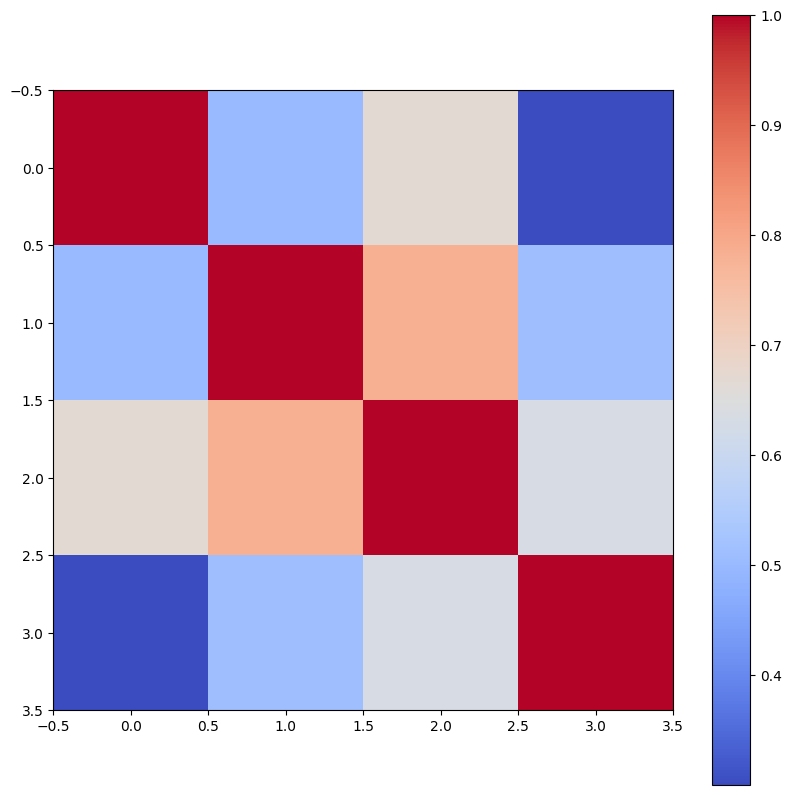

In [16]:
# Plot Correlation Matrix between X
corr_matrix = X.corr()
plt.figure(figsize=(10, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

## Modeling

In [ ]:
# 3. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

In [ ]:
# 4. Simple Naive Bayes Logic
def get_likelihood(X_feat, y_labels, bins=10):
    likelihoods = {}
    for cls in [0, 1]:
        feat_cls = X_feat[y_labels == cls].dropna()
        counts, edges = np.histogram(feat_cls, bins=bins, range=(X_feat.min(), X_feat.max()))
        # Laplace Smoothing
        prob = (counts + 1) / (counts.sum() + bins)
        likelihoods[cls] = (prob, edges)
    return likelihoods

# 5. Predict (T11)
print("Naive Bayes Training Complete.")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Naive Bayes Training Complete.
Train samples: 1323, Test samples: 147


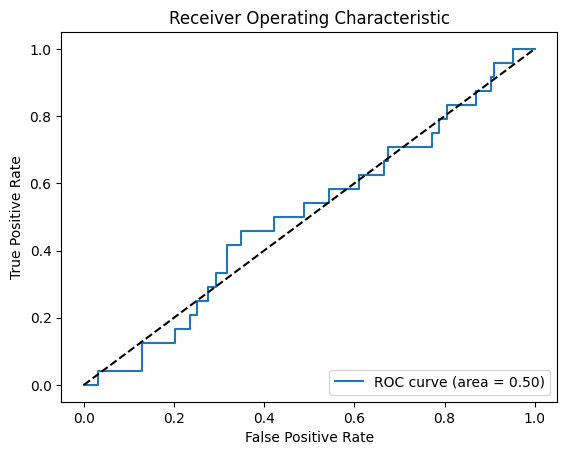

In [ ]:
# 6. ROC Curve (T17)
# สมมติค่า probability เพื่อวาดกราฟ
fpr, tpr, _ = roc_curve(y_test, np.random.rand(len(y_test))) # แทนด้วยค่าจริงจากโมเดล
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()